In [182]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from itertools import product

In [183]:
num_levels = 3
num_qubits = 4


J = -6 * 2 * np.pi
U = -180 * 2 * np.pi


In [266]:
annihilation_operators = []
for i in range(num_qubits):
    operator_list = [qt.qeye(num_levels)]*num_qubits
    operator_list[i] = qt.destroy(num_levels)
    annihilation_operators.append(qt.tensor(operator_list))

number_operators = [a_i.dag()*a_i for a_i in annihilation_operators]
n_1, n_2, n_3, n_4 = number_operators

number_operators_capped = []
for i in range(len(number_operators)):
    number_operators_capped.append(qt.Qobj(np.clip(number_operators[i].full(), 0, 1), dims=[[num_levels]*num_qubits]*2))

H = 0

for i in range(num_qubits):
    a_i = annihilation_operators[i]
    H += U/2 * a_i.dag() * a_i * (a_i.dag() * a_i - 1)

a_1, a_2, a_3, a_4 = annihilation_operators

H += J*(a_1.dag()*a_2 + a_2.dag()*a_1)
H += J*(a_3.dag()*a_4 + a_4.dag()*a_3)



current_operators = [1j*(a_1.dag()*a_2 - a_2.dag()*a_1),
                     1j*(a_3.dag()*a_4 - a_4.dag()*a_3)]

current_correlator = current_operators[0]*current_operators[1]


# restrict current correlator to subspace with at most one particle per site




In [268]:

current_correlator_restricted = np.copy(current_correlator.full())

basis = list(product(range(num_levels), repeat=num_qubits))

for i in range(len(basis)):
    state_1 = basis[i]
    for j in range(len(basis)):
        state_2 = basis[j]

        if state_1[1] == state_2[1] + 1:
            if state_1[0] == state_2[0] - 1:
                matrix_element = current_correlator_restricted[i,j].real
                if matrix_element >= 1e-10:
                    print(state_2, state_1, np.round(matrix_element, 3))


basis_restricted_indices = np.where([all(occ <= 1 for occ in state) for state in basis])[0]
print(basis_restricted_indices)


# Create inverse mask (indices to zero)
all_indices = np.arange(current_correlator_restricted.shape[0])
zero_indices = np.setdiff1d(all_indices, basis_restricted_indices)

# Zero out rows and columns
current_correlator_restricted[zero_indices, :] = 0
current_correlator_restricted[:, zero_indices] = 0

print(current_correlator_restricted)

current_correlator_restricted = qt.Qobj(current_correlator_restricted, dims=[[num_levels]*num_qubits]*2)

print('after zeroing')


for i in range(len(basis)):
    state_1 = basis[i]
    for j in range(len(basis)):
        state_2 = basis[j]

        if state_1[1] == state_2[1] + 1:
            if state_1[0] == state_2[0] - 1:
                matrix_element = current_correlator_restricted[i,j].real
                if matrix_element >= 1e-10:
                    print(state_2, state_1, np.round(matrix_element, 3))



(1, 0, 0, 1) (0, 1, 1, 0) 1.0
(1, 0, 0, 2) (0, 1, 1, 1) 1.414
(1, 0, 1, 1) (0, 1, 2, 0) 1.414
(1, 0, 1, 2) (0, 1, 2, 1) 2.0
(1, 1, 0, 1) (0, 2, 1, 0) 1.414
(1, 1, 0, 2) (0, 2, 1, 1) 2.0
(1, 1, 1, 1) (0, 2, 2, 0) 2.0
(1, 1, 1, 2) (0, 2, 2, 1) 2.828
(2, 0, 0, 1) (1, 1, 1, 0) 1.414
(2, 0, 0, 2) (1, 1, 1, 1) 2.0
(2, 0, 1, 1) (1, 1, 2, 0) 2.0
(2, 0, 1, 2) (1, 1, 2, 1) 2.828
(2, 1, 0, 1) (1, 2, 1, 0) 2.0
(2, 1, 0, 2) (1, 2, 1, 1) 2.828
(2, 1, 1, 1) (1, 2, 2, 0) 2.828
(2, 1, 1, 2) (1, 2, 2, 1) 4.0
[ 0  1  3  4  9 10 12 13 27 28 30 31 36 37 39 40]
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
after zeroing
(1, 0, 0, 1) (0, 1, 1, 0) 1.0


In [300]:
psi0_current_correlations = 0
psi0_current_correlations += qt.basis([num_levels]*num_qubits,[1,1,0,0])
psi0_current_correlations += 1j*qt.basis([num_levels]*num_qubits,[1,0,0,1])
psi0_current_correlations += 1j*qt.basis([num_levels]*num_qubits,[0,1,1,0])
psi0_current_correlations += -qt.basis([num_levels]*num_qubits,[0,0,1,1])
psi0_current_correlations = psi0_current_correlations.unit()

psi0_current_correlations_2 = 0
psi0_current_correlations_2 += qt.basis([num_levels]*num_qubits,[2,2,1,1])
psi0_current_correlations_2 += 1j*qt.basis([num_levels]*num_qubits,[2,1,1,2])
psi0_current_correlations_2 += 1j*qt.basis([num_levels]*num_qubits,[1,2,2,1])
psi0_current_correlations_2 += -qt.basis([num_levels]*num_qubits,[1,1,2,2])
psi0_current_correlations_2 = psi0_current_correlations_2.unit()



psi0_correlations_mixed = psi0_current_correlations*psi0_current_correlations.dag()





# mixed with vacuum
vacuum_state = qt.basis([num_levels]*num_qubits, [0]*num_qubits)
vacuum_state_mixed = vacuum_state*vacuum_state.dag()
psi0_correlations_mixed_1 = 1/2*(vacuum_state_mixed + psi0_correlations_mixed)

# mixed with 0012 and 0021
state_0012 = qt.basis([num_levels]*num_qubits, [0,0,1,2])
state_0012_mixed = state_0012*state_0012.dag()

state_0021 = qt.basis([num_levels]*num_qubits, [0,0,2,1])
state_0021_mixed = state_0021*state_0021.dag()

f = 0.5
psi0_correlations_mixed_2 = (1-f)*psi0_correlations_mixed + f/2*(state_0021_mixed + state_0012_mixed)


# mixed with a state with curren correlations on the higher states
psi0_correlations_mixed_3 = psi0_current_correlations*psi0_current_correlations.dag()/2 + psi0_current_correlations_2*psi0_current_correlations_2.dag()/2


psi0 = psi0_correlations_mixed
psi0 = psi0_correlations_mixed_1
psi0 = psi0_correlations_mixed_2
psi0 = psi0_correlations_mixed_3

# psi0 = psi0_current_correlations
# psi0 = psi0_current_correlations_2



print(psi0)





Quantum object: dims=[[3, 3, 3, 3], [3, 3, 3, 3]], shape=(81, 81), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [301]:
pair_1_mixed = psi0.ptrace([0,1])
print(pair_1_mixed)

pair_2_mixed = psi0.ptrace([2,3])
print(pair_2_mixed)

pair_basis = list(product(range(num_levels), repeat=2))
print(pair_basis)

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.125 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.125 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.125 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.25  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.125 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.125 0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.125]]
Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.125 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.125 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.125 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.25  0.    0.    0.    0.

In [302]:
times = np.linspace(0, 0.12, 101)

if psi0.isket:
    print(f'running sesolve')
    result = qt.sesolve(H, psi0, times)
elif psi0.isoper:
    print(f'running mesolve')
    result = qt.mesolve(H, psi0, times)

running mesolve


In [303]:
populations = np.zeros((num_qubits, len(times)))

for i in range(num_qubits):
    populations[i,:] = np.array([qt.expect(number_operators[i], state).real for state in result.states])

currents = [np.array([qt.expect(current_operators[0], state).real for state in result.states]),
            np.array([qt.expect(current_operators[1], state).real for state in result.states])]

current_correlation = np.array([qt.expect(current_correlator, state).real for state in result.states]) - currents[0]*currents[1]

current_correlation_restricted = np.array([qt.expect(current_correlator_restricted, state).real for state in result.states]) - currents[0]*currents[1]

covariances = np.zeros((num_qubits, num_qubits, len(times)))
covariances_capped = np.zeros((num_qubits, num_qubits, len(times)))

for i in range(num_qubits):
    for j in range(num_qubits):
        number_correlator = number_operators[i]*number_operators[j]
        number_correlator_capped = number_operators_capped[i]*number_operators_capped[j]

        covariances[i,j] = np.array([qt.expect(number_correlator, state).real for state in result.states])
        covariances_capped[i,j] = np.array([qt.expect(number_correlator_capped, state).real for state in result.states])

        covariances[i,j] -= populations[i]*populations[j]
        covariances_capped[i,j] -= populations[i]*populations[j]

covariance_sum = covariances[0,2] - covariances[0,3] - covariances[1,2] + covariances[1,3]
covariance_sum_capped = covariances_capped[0,2] - covariances_capped[0,3] - covariances_capped[1,2] + covariances_capped[1,3]

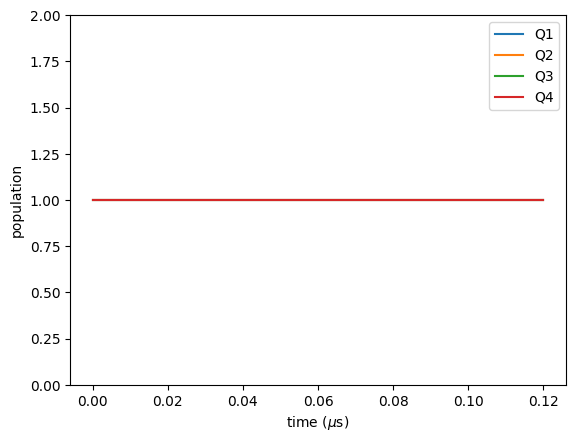

In [304]:
for i in range(num_qubits):
    plt.plot(times, populations[i], label=f'Q{i+1}')

plt.xlabel('time ($\mu$s)')
plt.ylabel('population')

plt.ylim(0, 2)

plt.legend()
plt.show()

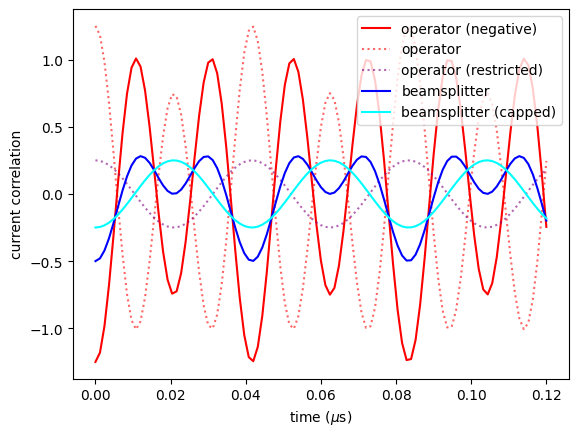

In [305]:
plt.plot(times, -current_correlation, color='red', label='operator (negative)')
plt.plot(times, current_correlation, color='red', linestyle=':', alpha=0.6, label='operator')
plt.plot(times, current_correlation_restricted, color='purple', linestyle=':', alpha=0.6, label='operator (restricted)')
plt.plot(times, covariance_sum, color='blue', label='beamsplitter')
plt.plot(times, covariance_sum_capped, color='cyan', label='beamsplitter (capped)')

plt.xlabel('time ($\mu$s)')
plt.ylabel('current correlation')

# plt.ylim(-0.55, 0.55)

plt.legend()
plt.show()

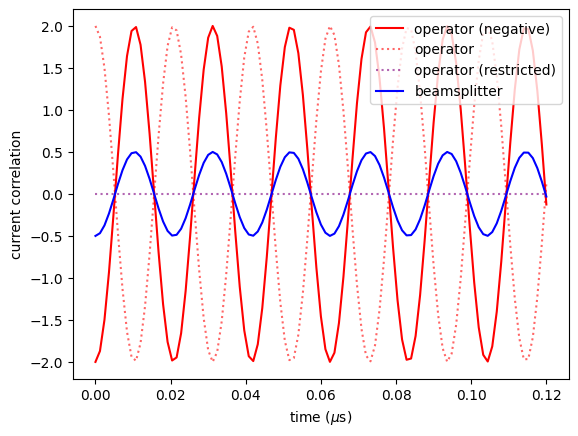